✅ Đã load mô hình thành công từ: ../models/model.joblib

--- BÁO CÁO ĐÁNH GIÁ CHI TIẾT (CLASSIFICATION REPORT) ---
              precision    recall  f1-score   support

           0       0.66      0.89      0.76       400
           1       0.62      0.29      0.40       256

    accuracy                           0.65       656
   macro avg       0.64      0.59      0.58       656
weighted avg       0.65      0.65      0.62       656



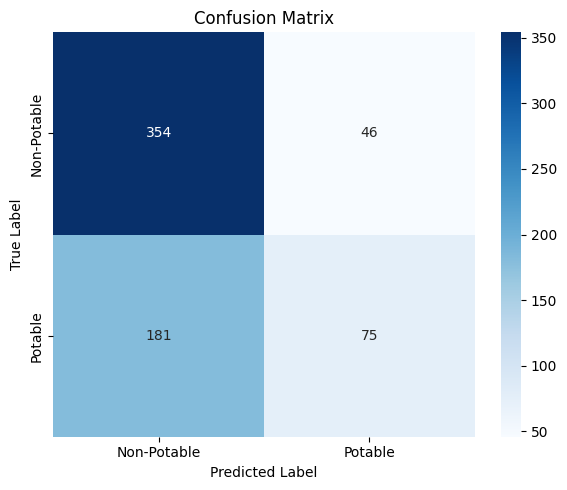

✅ Đã lưu hình: docs/figures/confusion_matrix.png


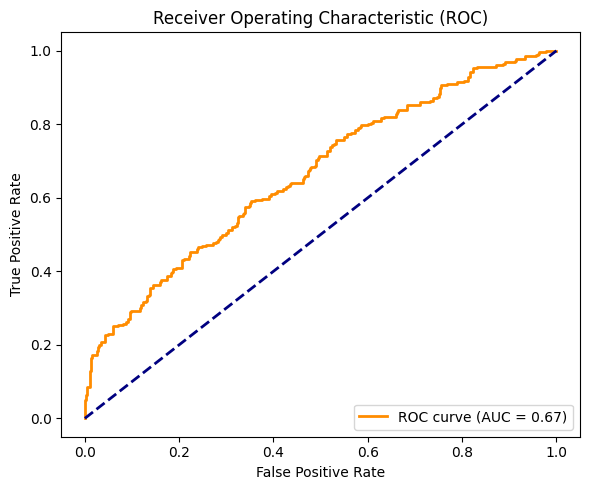

✅ Đã lưu hình: docs/figures/roc_curve.png


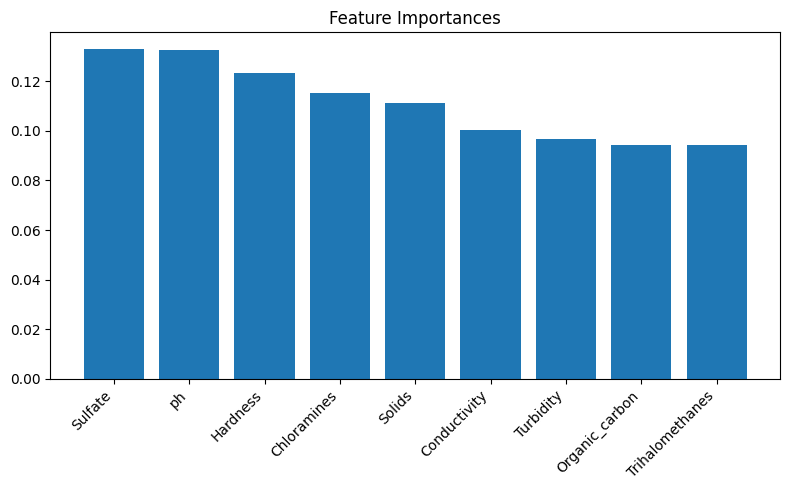

✅ Đã lưu hình: docs/figures/feature_importance.png


In [1]:
import os
import zipfile
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Đảm bảo thư mục docs/figures tồn tại
os.makedirs("../../docs/figures", exist_ok=True)

# 2. Đọc dữ liệu từ dataset.zip
zip_path = "../data/dataset.zip"
with zipfile.ZipFile(zip_path) as z:
    csv_filename = [f for f in z.namelist() if f.endswith(".csv")][0]
    with z.open(csv_filename) as f:
        df = pd.read_csv(f)

X = df.drop(columns=["Potability"])
y = df["Potability"]

# Phân chia lại tập Test đồng bộ với bước train
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Load mô hình chính thức đã huấn luyện
model_path = "../models/model.joblib"
model = joblib.load(model_path)
print(f"✅ Đã load mô hình thành công từ: {model_path}")

# 4. Thực hiện dự đoán trên tập Test
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

print("\n--- BÁO CÁO ĐÁNH GIÁ CHI TIẾT (CLASSIFICATION REPORT) ---")
print(classification_report(y_test, y_pred))

# 5. Vẽ và lưu Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Potable', 'Potable'], yticklabels=['Non-Potable', 'Potable'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('../../docs/figures/confusion_matrix.png', dpi=300)
plt.show()
print("✅ Đã lưu hình: docs/figures/confusion_matrix.png")

# 6. Vẽ và lưu Đường cong ROC Curve
if y_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig('../../docs/figures/roc_curve.png', dpi=300)
    plt.show()
    print("✅ Đã lưu hình: docs/figures/roc_curve.png")

# 7. Vẽ và lưu Feature Importance (Mức độ quan trọng đặc trưng)
if hasattr(model, 'named_steps') and hasattr(model.named_steps.get('rf', model.named_steps.get('knn')), 'feature_importances_'):
    importances = model.named_steps['rf'].feature_importances_
    features = X.columns
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(8, 5))
    plt.title("Feature Importances")
    plt.bar(range(X.shape[1]), importances[indices], align="center")
    plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../../docs/figures/feature_importance.png', dpi=300)
    plt.show()
    print("✅ Đã lưu hình: docs/figures/feature_importance.png")